## **DownLoad**

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from scipy.stats import pearsonr
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from matplotlib import pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor

### Data download from AWS

In [ ]:
'''!pip install boto3
import boto3
from botocore import UNSIGNED
from botocore.config import Config'''

In [ ]:
s3_client = boto3.client('s3', config=Config(signature_version=UNSIGNED))
bucket_name = 'amazon-bodym'
def list_files(bucket):
    # list files in an S3 bucket
    paginator = s3_client.get_paginator('list_objects_v2')
    try:
        page_iterator = paginator.paginate(Bucket=bucket)
        file_keys = []
        for page in page_iterator:
            if "Contents" in page:
                for obj in page['Contents']:
                    file_keys.append(obj['Key'])
        return file_keys
    except Exception as e:
        print("Error accessing bucket:", e)
        return None

file_keys = list_files(bucket_name)

In [ ]:
def download_files(bucket, file_keys, download_path='./data/'):
    # download files from an S3 bucket
    for key in file_keys:
        # ends with .png or .csv
        if key.endswith('.png') or key.endswith('.csv'):
            save_path = os.path.join(download_path, key)
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            # download the file
            try:
                s3_client.download_file(bucket, key, save_path)
                # print(f"Downloaded {save_path}")
            except Exception as e:
                print(f"Failed to download {key}: {e}")
download_files(bucket_name, file_keys)

## **Data**

### Analysis

In [2]:
train_image_dir_front = './data/train/mask/'
train_image_dir_left = './data/train/mask_left/'
val_image_dir_front = './data/testB/mask/'
val_image_dir_left = './data/testB/mask_left/'
test_image_dir_front = './data/testA/mask/'
test_image_dir_left = './data/testA/mask_left/'

In [3]:
train_metadata = pd.read_csv('./data/train/hwg_metadata.csv')
train_subject_to_photo_map = pd.read_csv('./data/train/subject_to_photo_map.csv')
train_measurements = pd.read_csv('./data/train/measurements.csv')

In [4]:
# load metadata
train_metadata.head()

,subject_id,gender,height_cm,weight_kg
0,AhfyGaD1BKo0-u6PeQk2oI-Bw5l0XxpAqNroFuZuy0I,female,160.00,92.4
1,E8tDQ5IgdBwbjLIXu7GwcupEHYbi0eB18YNcsgsSbP8,female,175.75,102.8
2,59bc2767681516389ccf45f9,male,174.80,106.9
3,nRatvgqbYTN77typTgGm4bAurxzpvf5nYg2Mb3gdh8c,male,181.50,111.8
4,fkq68ww6bdyKT16FavI1x_G-u7YZ9SoT1GNMUTSJUek,female,161.60,93.0


In [5]:
# load subject_to_photo_map
train_subject_to_photo_map.head()

,subject_id,photo_id
0,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,e6f404ebda41ebe93573d3e219c88297
1,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,39a4241cb892618a694747e224d57b9e
2,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,a00a6c0c074efbd92c894cbc77023939
3,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,7c99b3017f21f9797851e70de084bfcb
4,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,3000cb26b2090db5a7d82926af8c6a83


In [6]:
# load measurements
train_measurements.head()

,subject_id,ankle,arm-length,bicep,calf,chest,forearm,height,hip,leg-length,shoulder-breadth,shoulder-to-crotch,thigh,waist,wrist
0,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131
1,-5OHO2b5mRDY1rvAf07sYYtekEEX7ViEGmvRr7l4tfc,22.001783,46.763233,28.288971,35.649963,99.253395,24.813375,164.379623,92.128685,75.127258,33.848778,60.541386,52.418320,87.307899,15.192038
2,-5iHTazqnmWBsnUY6ymoCw1kORMymRDaUla1eNOjgvI,26.565006,53.288597,30.800959,39.854950,102.391273,27.719795,183.718842,106.044121,84.055527,37.856457,72.004379,52.934086,96.596413,17.936598
3,-60o95b9oEE83BDV3GpsAVPA4TFvxuPPqtXEY5PApy8,24.779566,49.077751,34.613113,38.104267,111.164070,28.550409,169.059113,109.529465,74.310234,38.197800,68.536713,58.656673,103.395119,17.029860
4,-67TrwlJ3GSsqPeHaa2Nb0iQ-BKZfIx4ERysQPZ0-SY,20.788853,42.229557,24.527142,29.181356,93.627777,21.979038,146.516632,87.134102,67.269859,31.659197,52.697277,41.844944,74.400856,15.120061


### Charts

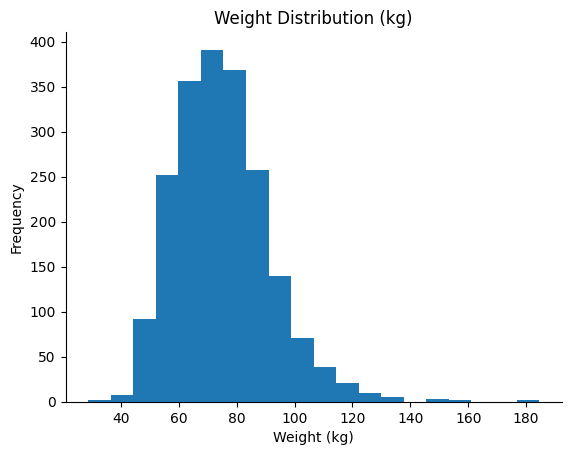

In [7]:
# @title weight_kg

from matplotlib import pyplot as plt
train_metadata['weight_kg'].plot(kind='hist', bins=20, title='Weight Distribution (kg)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.show()

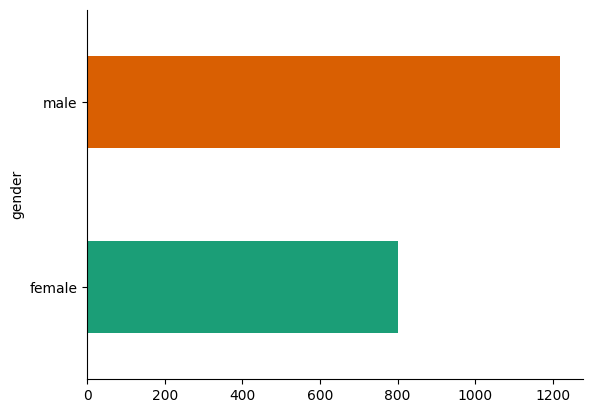

In [8]:
# @title gender

from matplotlib import pyplot as plt
import seaborn as sns
train_metadata.groupby('gender').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

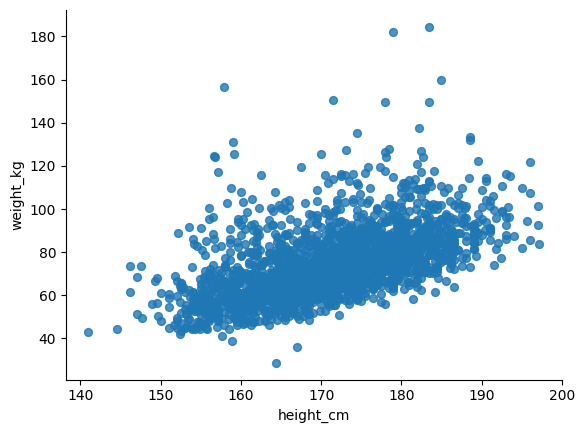

In [9]:
# @title height_cm vs weight_kg

from matplotlib import pyplot as plt
train_metadata.plot(kind='scatter', x='height_cm', y='weight_kg', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

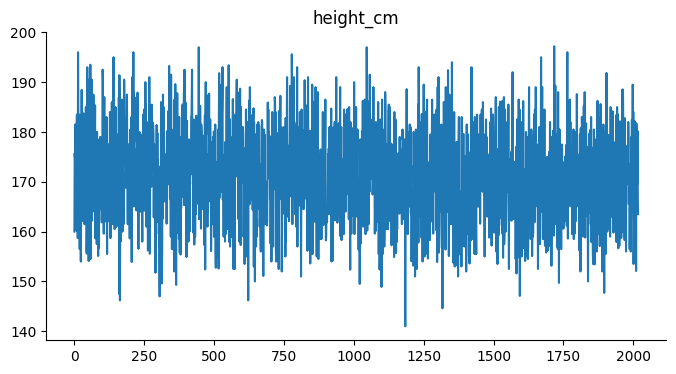

In [10]:
# @title height_cm

from matplotlib import pyplot as plt
train_metadata['height_cm'].plot(kind='line', figsize=(8, 4), title='height_cm')
plt.gca().spines[['top', 'right']].set_visible(False)

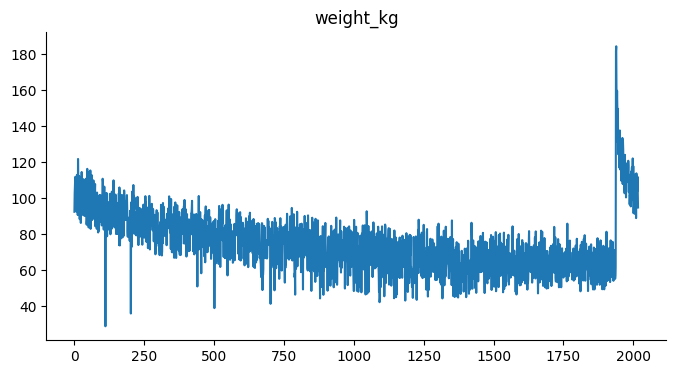

In [11]:
# @title weight_kg

from matplotlib import pyplot as plt
train_metadata['weight_kg'].plot(kind='line', figsize=(8, 4), title='weight_kg')
plt.gca().spines[['top', 'right']].set_visible(False)

C:\Users\Kai\AppData\Local\Temp\ipykernel_4624\1299051059.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(train_metadata, x='weight_kg', y='gender', inner='box', palette='Dark2')


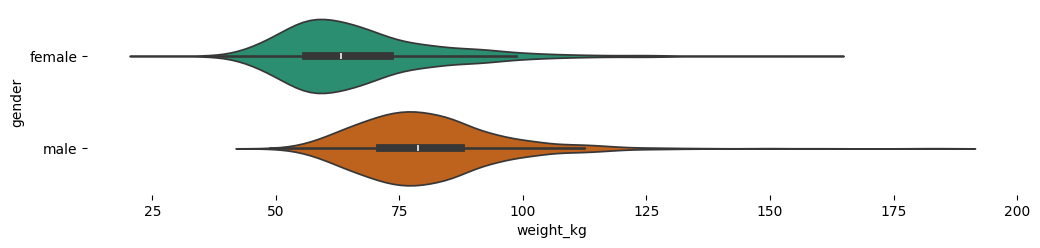

In [12]:
# @title gender vs weight_kg

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(train_metadata['gender'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(train_metadata, x='weight_kg', y='gender', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

C:\Users\Kai\AppData\Local\Temp\ipykernel_4624\1532629594.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(train_metadata, x='height_cm', y='gender', inner='box', palette='Dark2')


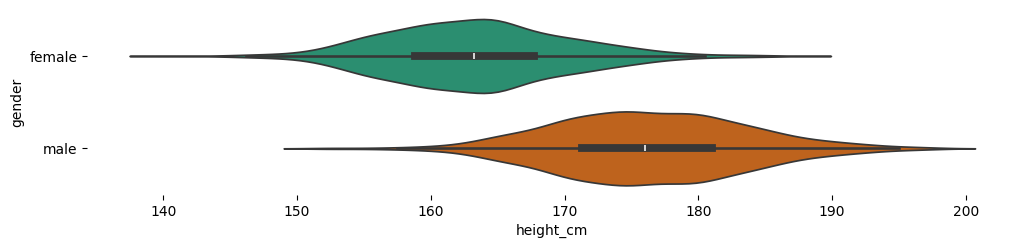

In [13]:
# @title gender vs height_cm

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(train_metadata['gender'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(train_metadata, x='height_cm', y='gender', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

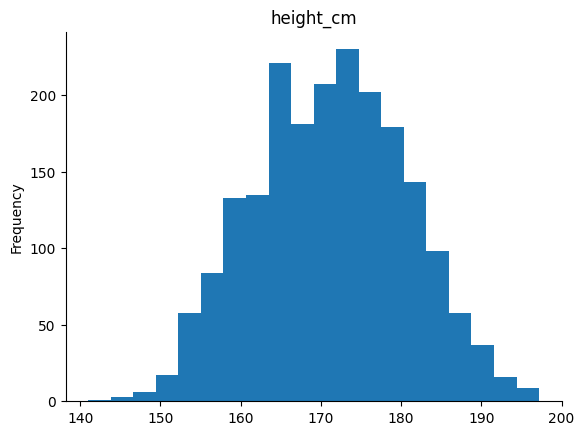

In [14]:
# @title height_cm

from matplotlib import pyplot as plt
train_metadata['height_cm'].plot(kind='hist', bins=20, title='height_cm')
plt.gca().spines[['top', 'right',]].set_visible(False)

### Data processing

In [15]:
def preprocess_data(base_dir, photo_map_filename, metadata_filename, measurements_filename, numerical_cols, categorical_cols, y_cols, use_images=True):
    photo_map = pd.read_csv(os.path.join(base_dir, photo_map_filename))
    metadata = pd.read_csv(os.path.join(base_dir, metadata_filename))
    measurements = pd.read_csv(os.path.join(base_dir, measurements_filename))

    valid_subject_ids = set(photo_map['subject_id']).intersection(set(metadata['subject_id'])).intersection(set(measurements['subject_id']))
    # filter each dataset by valid subject_ids
    photo_map = photo_map[photo_map['subject_id'].isin(valid_subject_ids)]
    metadata = metadata[metadata['subject_id'].isin(valid_subject_ids)]
    measurements = measurements[measurements['subject_id'].isin(valid_subject_ids)]

    # join photo_map with metadata and measurements
    full_data = photo_map.merge(metadata, on='subject_id').merge(measurements, on='subject_id')

    # prepare feature and label data
    X = full_data[numerical_cols + categorical_cols]
    y = full_data[y_cols].values
    gender = full_data['gender'].values

    # preprocessing for numerical and categorical data
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])

    X_transformed = preprocessor.fit_transform(X)

    target_scaler = StandardScaler()
    y_scaled = target_scaler.fit_transform(y)

    if use_images:
        front_images = load_images_parallel(os.path.join(base_dir, 'mask'), full_data['photo_id'])
        left_images = load_images_parallel(os.path.join(base_dir, 'mask_left'), full_data['photo_id'])
    else:
        front_images = None
        left_images = None

    return {
        'X_transformed': X_transformed,
        'gender': gender,
        'y_scaler': target_scaler,
        'y_scaled': y_scaled,
        'y': y,
        'front_images': front_images,
        'left_images': left_images,
        'original_data': X,
    }

def load_image(img_path):
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        return None
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (128, 128))
        img = np.expand_dims(img, axis=-1) / 255.0  # Normalize the image
        return img
    else:
        print(f"Failed to load image: {img_path}")
        return None

def load_images_parallel(folder, photo_ids):
    img_paths = [os.path.join(folder, f'{photo_id}.png') for photo_id in photo_ids]
    with ThreadPoolExecutor() as executor:
        images = list(executor.map(load_image, img_paths))
    images = [img for img in images if img is not None]
    if not images:
        print(f"No images loaded from {folder}")
    return np.array(images)

In [16]:
photo_map_file = 'subject_to_photo_map.csv'
metadata_file = 'hwg_metadata.csv'
measurements_file = 'measurements.csv'
numerical_cols_list = ['height_cm', 'weight_kg']
categorical_cols_list = ['gender']
y_cols_list = ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip', 'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']

train_data = preprocess_data(
    base_dir = './data/train',
    photo_map_filename = photo_map_file,
    metadata_filename = metadata_file,
    measurements_filename = measurements_file,
    numerical_cols = numerical_cols_list,
    categorical_cols = categorical_cols_list,
    y_cols = y_cols_list
)

val_data = preprocess_data(
    base_dir='./data/testB',
    photo_map_filename = photo_map_file,
    metadata_filename = metadata_file,
    measurements_filename = measurements_file,
    numerical_cols = numerical_cols_list,
    categorical_cols = categorical_cols_list,
    y_cols = y_cols_list    
)

test_data = preprocess_data(
    base_dir='./data/testA',
    photo_map_filename = photo_map_file,
    metadata_filename = metadata_file,
    measurements_filename = measurements_file,
    numerical_cols = numerical_cols_list,
    categorical_cols = categorical_cols_list,
    y_cols = y_cols_list
)

In [17]:
print("Train front images shape:", train_data['front_images'].shape)
print("Train left images shape:", train_data['left_images'].shape)

Train front images shape: (6134, 128, 128, 1)
Train left images shape: (6134, 128, 128, 1)


In [18]:
print("Train X features images shape:", train_data['X_transformed'].shape)

Train X features images shape: (6134, 4)


## **CNN**

### Train

In [19]:
def define_image_branch(input_tensor):
    x = Conv2D(32, (3, 3), activation='relu')(input_tensor)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    return Flatten()(x)

input_front = Input(shape=(128, 128, 1), name='input_front')
input_left = Input(shape=(128, 128, 1), name='input_left')
input_numerical = Input(shape=(train_data['X_transformed'].shape[1],), name='input_numerical')

x_front = define_image_branch(input_front)
x_left = define_image_branch(input_left)
combined = concatenate([x_front, x_left, Dense(32, activation='relu')(input_numerical)])
output = Dense(14, activation='linear', name='output')(combined)

model = Model(inputs=[input_front, input_left, input_numerical], outputs=output)
model.compile(optimizer=Adam(), loss='mse')
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_front         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_left          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        320 │ input_front[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 126, 126,  │        320 │ input_left[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 63, 63,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 30, 30,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numerical     │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 57600)     │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 57600)     │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        160 │ input_numerical[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 115232)    │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 14)        │  1,613,262 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,651,054 (6.30 MB)

 Trainable params: 1,651,054 (6.30 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    [train_data['front_images'], train_data['left_images'], train_data['X_transformed']],
    train_data['y_scaled'],
    validation_data=([val_data['front_images'], val_data['left_images'], val_data['X_transformed']], val_data['y_scaled']),
    epochs=10,
    batch_size=32
)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 32s 159ms/step - loss: 0.7773 - val_loss: 0.2103
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 159ms/step - loss: 0.1363 - val_loss: 0.1834
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 158ms/step - loss: 0.1014 - val_loss: 0.1836
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - loss: 0.0807 - val_loss: 0.1788
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - loss: 0.0688 - val_loss: 0.1774
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - loss: 0.0567 - val_loss: 0.1927
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - loss: 0.0487 - val_loss: 0.1870
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step - loss: 0.0399 - val_loss: 0.1937
Epoch 9/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - loss: 0.0328 - val_loss: 0.1919
Epoch 10/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - loss: 0.0286 - val_loss: 0.1975


In [21]:
model.save('./save/bodyM_model_w.keras')

### Test

In [22]:
test_loss_with_images = model.evaluate(
    [test_data['front_images'], test_data['left_images'], test_data['X_transformed']],
    test_data['y_scaled']
)

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1597


In [23]:
predictions_scaled = model.predict([test_data['front_images'], test_data['left_images'], test_data['X_transformed']])
predictions = test_data['y_scaler'].inverse_transform(predictions_scaled)
mse_with_images = mean_squared_error(test_data['y'], predictions)
print("Mean Squared Error on testA Data:", mse_with_images)

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
Mean Squared Error on testA Data: 3.3203569248622964


In [24]:
test_all_data = {
        'X_transformed': np.concatenate((test_data['X_transformed'], val_data['X_transformed']), axis=0),
        'gender': np.concatenate((test_data['gender'], val_data['gender']), axis=0),
        'y': np.concatenate((test_data['y'], val_data['y']), axis=0),
        'y_scaled': np.concatenate((test_data['y_scaled'], val_data['y_scaled']), axis=0),
        'y_scaler': test_data['y_scaler'],
        'front_images': np.concatenate((test_data['front_images'], val_data['front_images']), axis=0),
        'left_images': np.concatenate((test_data['left_images'], val_data['left_images']), axis=0)
    }

In [25]:
predictions_scaled = model.predict([test_all_data['front_images'], test_all_data['left_images'], test_all_data['X_transformed']])
predictions = test_data['y_scaler'].inverse_transform(predictions_scaled)
mse_all_with_images = mean_squared_error(test_all_data['y'], predictions)
print("Mean Squared Error on all Data:", mse_all_with_images)

89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step
Mean Squared Error on all Data: 5.66795260974326


### Analysis

In [26]:
errors = np.mean((predictions - test_all_data['y']) ** 2, axis=1)
sorted_indices = np.argsort(errors)

# preparing data for the best and worst cases
best_indices = sorted_indices[:3]
worst_indices = sorted_indices[-3:]

# load images for the best and worst cases
best_images_front = test_all_data['front_images'][best_indices]
best_images_left = test_all_data['left_images'][best_indices]
worst_images_front = test_all_data['front_images'][worst_indices]
worst_images_left = test_all_data['left_images'][worst_indices]

# prepare predictions and actuals using indices directly
best_predictions = predictions[best_indices]
best_actuals = test_all_data['y'][best_indices]
worst_predictions = predictions[worst_indices]
worst_actuals = test_all_data['y'][worst_indices]

In [27]:
def plot_with_table(front_images, left_images, predictions, actuals, title):
    num_subjects = len(front_images)
    fig, axs = plt.subplots(3, num_subjects, figsize=(num_subjects * 4, 12))
    cols = ['Predicted', 'Actual']
    rows = ['Ankle', 'Arm Length', 'Bicep', 'Calf', 'Chest', 'Forearm', 'Height', 'Hip', 'Leg Length', 'Shoulder Breadth', 'Shoulder to Crotch', 'Thigh', 'Waist', 'Wrist']
    col_widths = [0.2, 0.2]  

    for i in range(num_subjects):
        # plot front mask image
        axs[0, i].imshow(front_images[i].squeeze(), cmap='gray')
        axs[0, i].axis('off')
        axs[0, i].set_title("Front Mask")

        # plot left mask image
        axs[1, i].imshow(left_images[i].squeeze(), cmap='gray')
        axs[1, i].axis('off')
        axs[1, i].set_title("Left Mask")

        # plot table
        cell_text = [[f"{p:.2f}", f"{a:.2f}"] for p, a in zip(predictions[i], actuals[i])]
        ax = axs[2, i] 
        ax.axis('off')
        table = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols, loc='center', cellLoc='center', colWidths=col_widths)
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1.2, 1.4) 

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

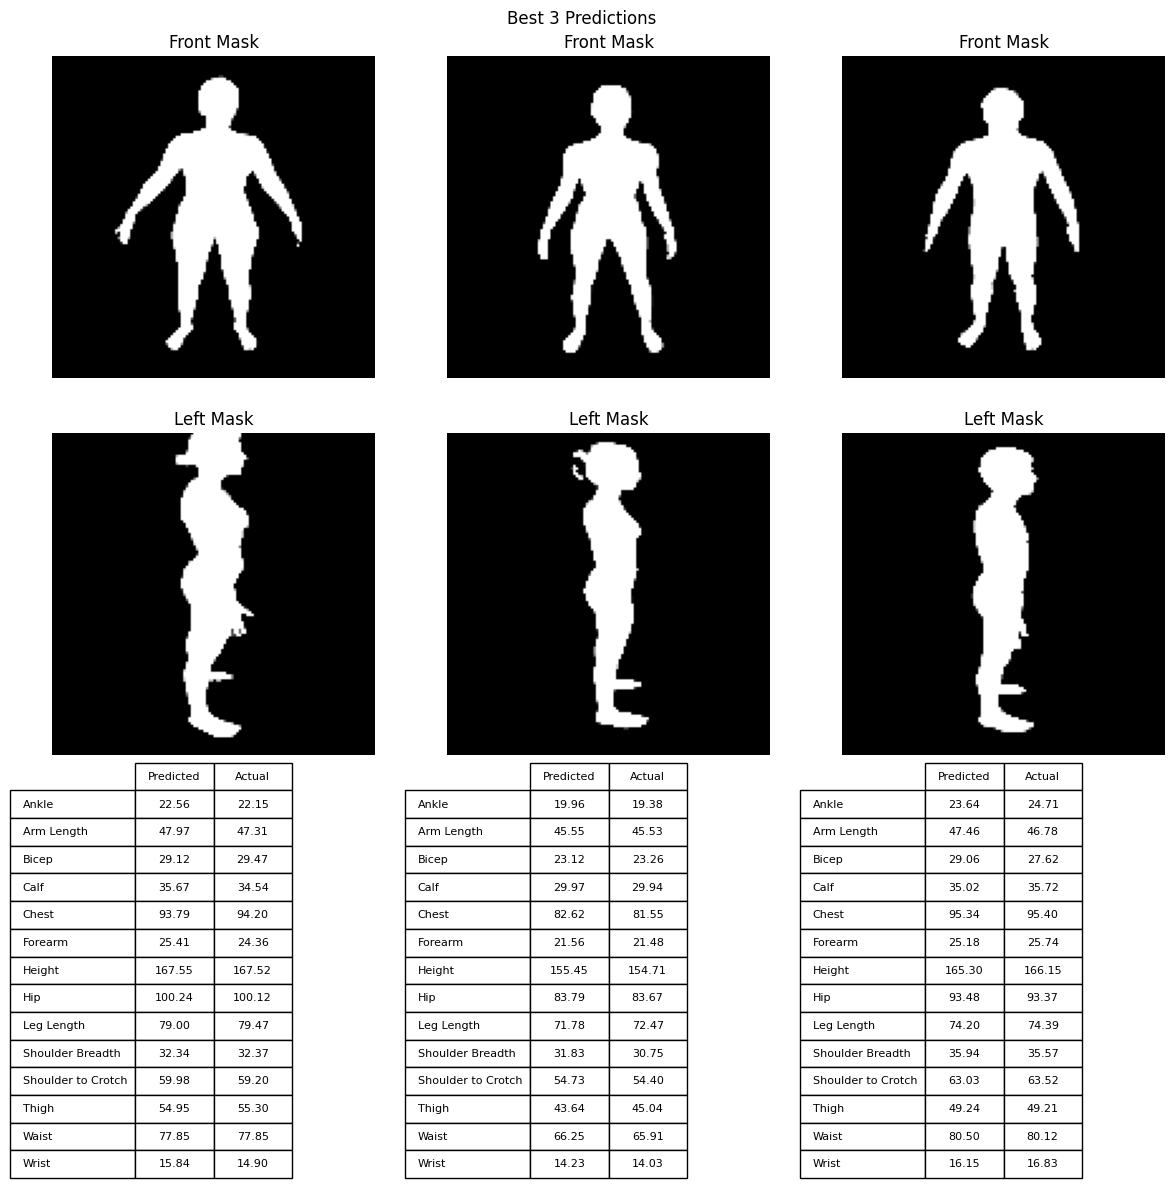

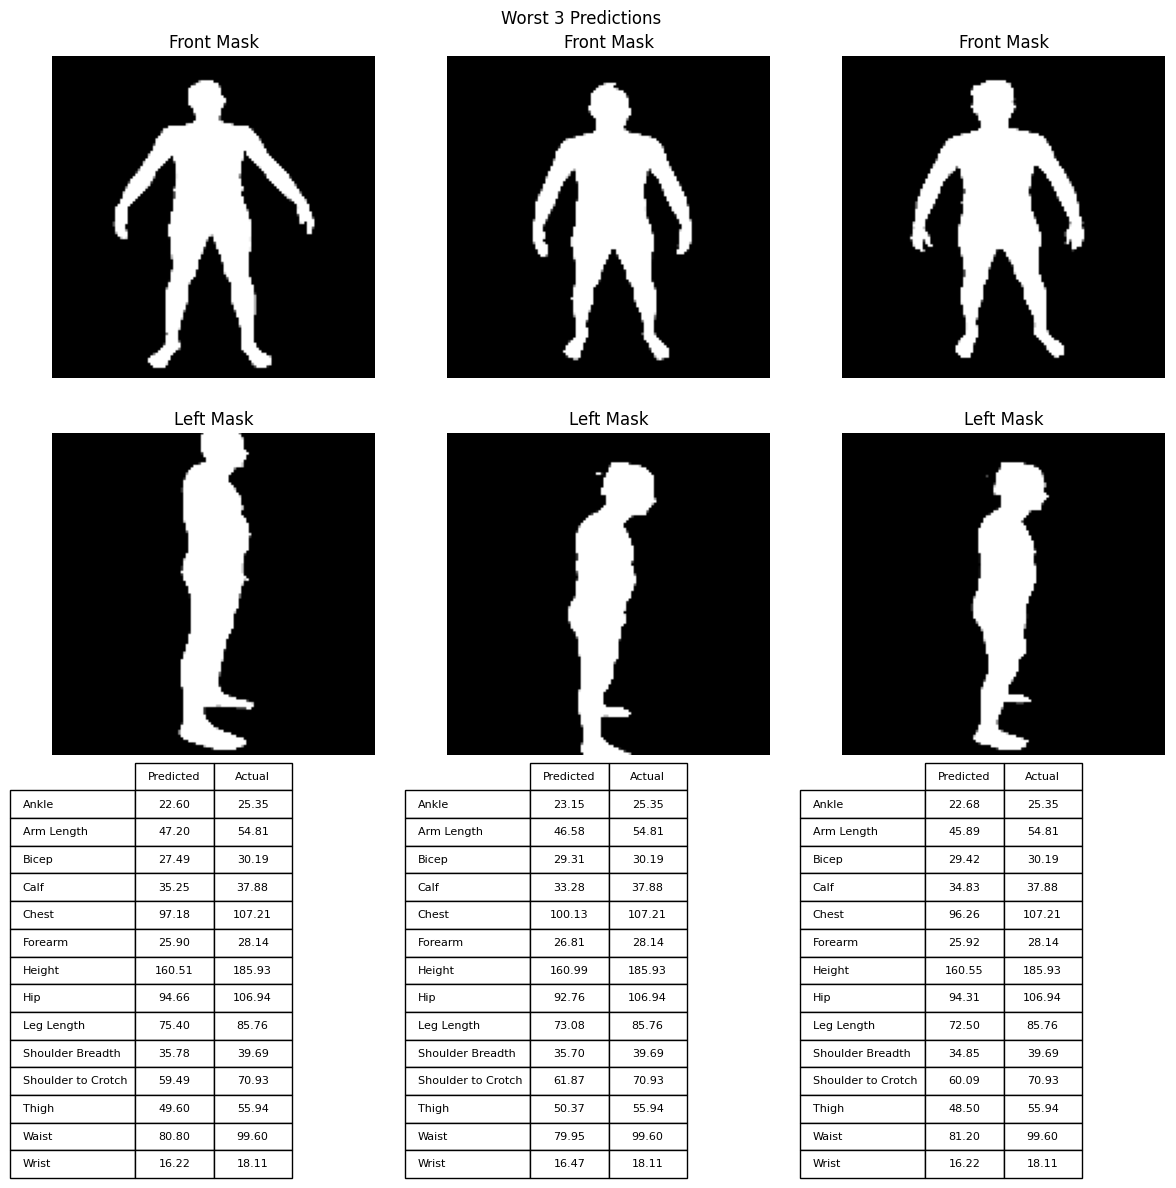

In [28]:
plot_with_table(best_images_front, best_images_left, best_predictions, best_actuals, "Best 3 Predictions")
plot_with_table(worst_images_front, worst_images_left, worst_predictions, worst_actuals, "Worst 3 Predictions")

In [29]:
mse_per_measurement = {}
for i, measurement in enumerate(y_cols_list): 
    mse = mean_squared_error(test_all_data['y'][:, i], predictions[:, i])
    mse_per_measurement[measurement] = mse

sorted_measurements = sorted(mse_per_measurement.items(), key=lambda x: x[1], reverse=True)
print("MSE by Measurement:")
for measure, mse in sorted_measurements:
    print(f"{measure}: {mse:.4f}")

MSE by Measurement:
waist: 22.2684
chest: 14.6343
hip: 9.7304
height: 7.6331
leg-length: 6.6511
thigh: 4.1584
bicep: 3.3559
shoulder-to-crotch: 2.6075
calf: 2.4220
arm-length: 2.1463
forearm: 1.2134
ankle: 1.0367
shoulder-breadth: 0.9407
wrist: 0.5531


In [30]:
gender_labels = test_all_data['gender'] 
gender_errors = {'male': [], 'female': []}

for i, gender in enumerate(gender_labels):
    error = np.mean((predictions[i] - test_all_data['y'][i]) ** 2) 
    if gender == 'male':
        gender_errors['male'].append(error)
    elif gender == 'female':
        gender_errors['female'].append(error)

avg_error_by_gender = {gender: np.mean(errors) for gender, errors in gender_errors.items()}
print("Average MSE by Gender:")
for gender, error in avg_error_by_gender.items():
    print(f"{gender}: {error:.4f}")

Average MSE by Gender:
male: 5.6173
female: 5.7125


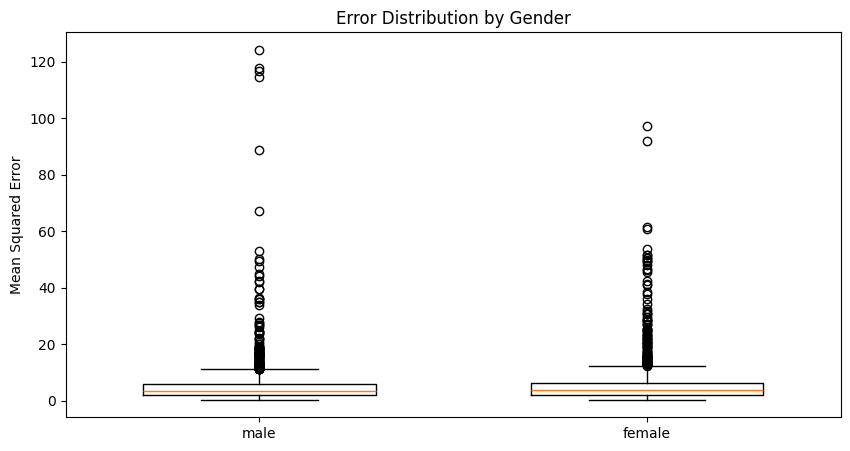

In [31]:
plt.figure(figsize=(10, 5))
positions = [1 if gender == 'male' else 2 for gender in gender_errors.keys()]
plt.boxplot([gender_errors['male'], gender_errors['female']], positions=positions, widths=0.6, tick_labels=['male', 'female'])
plt.title('Error Distribution by Gender')
plt.ylabel('Mean Squared Error')
plt.show()

## **Without silhouettes**

In [32]:
train_data_no_images = preprocess_data(
    base_dir = './data/train',
    photo_map_filename = photo_map_file,
    metadata_filename = metadata_file,
    measurements_filename = measurements_file,
    numerical_cols = numerical_cols_list,
    categorical_cols = categorical_cols_list,
    y_cols = y_cols_list,
    use_images=False
)

val_data_no_images = preprocess_data(
    base_dir='./data/testB',
    photo_map_filename = photo_map_file,
    metadata_filename = metadata_file,
    measurements_filename = measurements_file,
    numerical_cols = numerical_cols_list,
    categorical_cols = categorical_cols_list,
    y_cols = y_cols_list,
    use_images=False
)

test_data_no_images = preprocess_data(
    base_dir='./data/testA',
    photo_map_filename = photo_map_file,
    metadata_filename = metadata_file,
    measurements_filename = measurements_file,
    numerical_cols = numerical_cols_list,
    categorical_cols = categorical_cols_list,
    y_cols = y_cols_list,
    use_images=False
)

In [33]:
input_numerical_no_images = Input(shape=(train_data_no_images['X_transformed'].shape[1],), name='input_numerical')

combined_no_images = Dense(32, activation='relu')(input_numerical_no_images)

output_no_images = Dense(14, activation='linear', name='output')(combined_no_images)

model_no_images = Model(inputs=[input_numerical_no_images], outputs=output_no_images)
model_no_images.compile(optimizer=Adam(), loss='mse')

history_no_images = model_no_images.fit(
    train_data_no_images['X_transformed'],
    train_data_no_images['y_scaled'],
    validation_data=(val_data_no_images['X_transformed'], val_data_no_images['y_scaled']),
    epochs=10,
    batch_size=32
)

test_loss_no_images = model_no_images.evaluate(test_data_no_images['X_transformed'], test_data_no_images['y_scaled'])

print(f"Test Loss without images: {test_loss_no_images:.4f}")

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6924 - val_loss: 0.2391
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1966 - val_loss: 0.1951
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1661 - val_loss: 0.1909
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1613 - val_loss: 0.1899
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1588 - val_loss: 0.1873
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1573 - val_loss: 0.1873
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1571 - val_loss: 0.1841
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1556 - val_loss: 0.1860
Epoch 9/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1541 - val_loss: 0.1837
Epoch 10/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1549 - val_loss: 0.1845
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step - loss: 0.1901
Test Loss without images: 0.1824


In [34]:
model_no_images.save('./save/bodyM_model_wo.keras')

In [35]:
predictions_scaled_no_images = model_no_images.predict(test_data_no_images['X_transformed'])
predictions_no_images = test_data_no_images['y_scaler'].inverse_transform(predictions_scaled_no_images)
mse_no_images = mean_squared_error(test_data_no_images['y'], predictions_no_images)
print("Mean Squared Error on testA Data without images:", mse_no_images)

test_all_data_no_images = {
    'X_transformed': np.concatenate((test_data_no_images['X_transformed'], val_data_no_images['X_transformed']), axis=0),
    'gender': np.concatenate((test_data_no_images['gender'], val_data_no_images['gender']), axis=0),
    'y': np.concatenate((test_data_no_images['y'], val_data_no_images['y']), axis=0),
    'y_scaled': np.concatenate((test_data_no_images['y_scaled'], val_data_no_images['y_scaled']), axis=0),
    'y_scaler': test_data_no_images['y_scaler']
}

predictions_scaled_all_no_images = model_no_images.predict(test_all_data_no_images['X_transformed'])
predictions_all_no_images = test_all_data_no_images['y_scaler'].inverse_transform(predictions_scaled_all_no_images)
mse_all_no_images = mean_squared_error(test_all_data_no_images['y'], predictions_all_no_images)
print("Mean Squared Error on all Data without images:", mse_all_no_images)

mse_per_measurement_no_images = {}
for i, measurement in enumerate(y_cols_list):
    mse = mean_squared_error(test_all_data_no_images['y'][:, i], predictions_all_no_images[:, i])
    mse_per_measurement_no_images[measurement] = mse

sorted_measurements_no_images = sorted(mse_per_measurement_no_images.items(), key=lambda x: x[1], reverse=True)
print("MSE by Measurement without images:")
for measure, mse in sorted_measurements_no_images:
    print(f"{measure}: {mse:.4f}")

gender_labels_no_images = test_all_data_no_images['gender']
gender_errors_no_images = {'male': [], 'female': []}

for i, gender in enumerate(gender_labels_no_images):
    error = np.mean((predictions_all_no_images[i] - test_all_data_no_images['y'][i]) ** 2)
    if gender == 'male':
        gender_errors_no_images['male'].append(error)
    elif gender == 'female':
        gender_errors_no_images['female'].append(error)

avg_error_by_gender_no_images = {gender: np.mean(errors) for gender, errors in gender_errors_no_images.items()}
print("Average MSE by Gender without images:")
for gender, error in avg_error_by_gender_no_images.items():
    print(f"{gender}: {error:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Squared Error on testA Data without images: 3.9239011617881863
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step
Mean Squared Error on all Data without images: 6.493555568977395
MSE by Measurement without images:
waist: 25.4191
chest: 16.5666
hip: 11.9402
height: 8.7119
leg-length: 7.5381
thigh: 5.0455
calf: 3.7471
bicep: 2.9957
shoulder-to-crotch: 2.5927
arm-length: 2.5441
forearm: 1.2586
ankle: 1.0966
shoulder-breadth: 0.9371
wrist: 0.5166
Average MSE by Gender without images:
male: 6.9088
female: 6.1288


## **EVAL**

In [36]:
improvement = (test_loss_no_images - test_loss_with_images) / test_loss_no_images * 100
print(f"Performance Improvement: {improvement:.2f}%")

Performance Improvement: 15.12%


In [37]:
improvement_testA = (mse_no_images - mse_with_images) / mse_no_images * 100
improvement_all = (mse_all_no_images - mse_all_with_images) / mse_all_no_images * 100

print(f"Performance Improvement on testA Data: {improvement_testA:.2f}%")
print(f"Performance Improvement on all Data: {improvement_all:.2f}%")

Performance Improvement on testA Data: 15.38%
Performance Improvement on all Data: 12.71%


In [38]:
mse_measurement_df = pd.DataFrame({
    'Measurement': y_cols_list,
    'MSE without Images': [mse_per_measurement_no_images[m] for m in y_cols_list],
    'MSE with Images': [mse_per_measurement[m] for m in y_cols_list],
})

mse_measurement_df['Difference'] = mse_measurement_df['MSE without Images'] - mse_measurement_df['MSE with Images']
mse_measurement_df = mse_measurement_df.sort_values(by='Difference', ascending=False)
print(mse_measurement_df)

           Measurement  MSE without Images  MSE with Images  Difference
12               waist           25.419135        22.268442    3.150693
7                  hip           11.940249         9.730442    2.209808
4                chest           16.566592        14.634345    1.932247
3                 calf            3.747116         2.421956    1.325159
6               height            8.711926         7.633051    1.078875
11               thigh            5.045464         4.158395    0.887069
8           leg-length            7.538066         6.651113    0.886953
1           arm-length            2.544060         2.146267    0.397793
0                ankle            1.096552         1.036728    0.059823
5              forearm            1.258602         1.213418    0.045185
9     shoulder-breadth            0.937074         0.940691   -0.003617
10  shoulder-to-crotch            2.592671         2.607455   -0.014785
13               wrist            0.516569         0.553106   -0

In [39]:
gender_mse_df = pd.DataFrame({
    'Gender': ['male', 'female'],
    'MSE without Images': [avg_error_by_gender_no_images['male'], avg_error_by_gender_no_images['female']],
    'MSE with Images': [avg_error_by_gender['male'], avg_error_by_gender['female']],
})

gender_mse_df['Difference'] = gender_mse_df['MSE without Images'] - gender_mse_df['MSE with Images']
print(gender_mse_df)

   Gender  MSE without Images  MSE with Images  Difference
0    male            6.908824         5.617260    1.291564
1  female            6.128756         5.712485    0.416271


In [40]:
correlation_with_images, _ = pearsonr(test_all_data['y'].flatten(), predictions.flatten())
print(f'Correlation (with images): {correlation_with_images:.6f}')

correlation_no_images, _ = pearsonr(test_all_data_no_images['y'].flatten(), predictions_all_no_images.flatten())
print(f'Correlation (without images): {correlation_no_images:.6f}')

Correlation (with images): 0.998315
Correlation (without images): 0.998071


In [41]:
r2_with_images = r2_score(test_all_data['y'], predictions)
mae_with_images = mean_absolute_error(test_all_data['y'], predictions)
mape_with_images = mean_absolute_percentage_error(test_all_data['y'], predictions)
print(f"R² (with images): {r2_with_images:.4f}")
print(f"MAE (with images): {mae_with_images:.4f}")
print(f"MAPE (with images): {mape_with_images:.4f}")

r2_no_images = r2_score(test_all_data_no_images['y'], predictions_all_no_images)
mae_no_images = mean_absolute_error(test_all_data_no_images['y'], predictions_all_no_images)
mape_no_images = mean_absolute_percentage_error(test_all_data_no_images['y'], predictions_all_no_images)
print(f"R² (without images): {r2_no_images:.4f}")
print(f"MAE (without images): {mae_no_images:.4f}")
print(f"MAPE (without images): {mape_no_images:.4f}")

R² (with images): 0.8153
MAE (with images): 1.5718
MAPE (with images): 0.0286
R² (without images): 0.7948
MAE (without images): 1.6763
MAPE (without images): 0.0299
